# Q1 — Ice Cloud Spatial Distribution (Jan–Dec 2025)

Annual mean ice cloud occurrence fraction and instrument comparison for EarthCARE
ATLID-based products over January–December 2025, 1° × 1° grid.

| Figure | Content | Data |
|--------|---------|------|
| 1a | ATL-TC ice cloud occurrence — lat/lon | ATL_TC_2A monthly |
| 1b | ATL-TC ice cloud occurrence — lat/height | ATL_TC_2A monthly |
| 2a | AC-TC ice cloud occurrence — lat/lon | AC_TC_2B monthly |
| 2b | AC-TC ice cloud occurrence — lat/height | AC_TC_2B monthly |
| 3a | Ice cloud diff (AC-TC − ATL-TC) — lat/lon | derived |
| 3b | Ice cloud diff (AC-TC − ATL-TC) — lat/height | derived |
| 4a | All-cloud diff (AC-TC − ATL-TC) — lat/lon | v2 annual |
| 4b | All-cloud diff (AC-TC − ATL-TC) — lat/height | v2 annual |

In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.ndimage import gaussian_filter, median_filter
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
BASE    = Path("/Users/tobiasraucher/Python/KNMI")
ATL_DIR = BASE / "data/level2a/ATL_TC__2A"
AC_DIR  = BASE / "data/level2b/AC__TC__2B"
V2_DIR  = BASE / "data/v2_data"
OUT_DIR = BASE / "output/figures"
OUT_DIR.mkdir(exist_ok=True)

MIN_COUNT           = 10
H_MIN_KM, H_MAX_KM = 0.5, 20.0
VMAX_LL, VMAX_LH   = 0.25, 0.30
MEDIAN, MEDIAN_SIZE = True, 3
SMOOTH              = True
SIGMA_LL, SIGMA_LH = 1.5, 1.0

MONTHS_2025 = [
    "20250101_20250131", "20250201_20250228", "20250301_20250331",
    "20250401_20250430", "20250501_20250531", "20250601_20250630",
    "20250701_20250731", "20250801_20250831", "20250901_20250930",
    "20251001_20251031", "20251101_20251130", "20251201_20251231",
]

In [3]:
def smooth_map(data, sigma):
    """NaN-preserving median + Gaussian smooth."""
    out = data.copy().astype(float)
    if MEDIAN:
        nan_mask = np.isnan(out)
        filled   = np.where(nan_mask, np.nanmedian(out), out)
        out      = np.where(nan_mask, np.nan, median_filter(filled, size=MEDIAN_SIZE))
    if SMOOTH:
        nan_mask = np.isnan(out)
        filled   = np.where(nan_mask, 0.0, out)
        weights  = (~nan_mask).astype(float)
        s_vals   = gaussian_filter(filled,  sigma=sigma)
        s_wts    = gaussian_filter(weights, sigma=sigma)
        out      = np.where(s_wts > 0.1, s_vals / s_wts, np.nan)
    return out


def load_ice_months(data_dir, prefix, month_stems, suffix):
    """Aggregate monthly ice count NetCDF files; return (occ_raw, coords)."""
    ice_s = tot_s = None
    coords = {}
    for m in month_stems:
        path = data_dir / f"{prefix}_{m}_{suffix}.nc"
        ds = xr.open_dataset(path)
        if ice_s is None:
            ice_s  = ds["ice_count"].values.copy()
            tot_s  = ds["total_count"].values.copy()
            coords = {k: ds[k].values for k in ds.coords}
        else:
            ice_s += ds["ice_count"].values
            tot_s += ds["total_count"].values
        ds.close()
    occ = np.divide(
        ice_s, tot_s,
        out=np.full_like(ice_s, np.nan, dtype=float),
        where=tot_s >= MIN_COUNT,
    )
    return occ, coords


def print_stats(arr, label="Occurrence", is_diff=False):
    """Extended descriptive statistics."""
    vals = arr[~np.isnan(arr)]
    sep = "─" * 3
    print(f"{sep} {label} {sep}")
    print(f"  Array shape : {arr.shape}")
    print(f"  Valid cells : {len(vals):,} / {arr.size:,}  ({100*len(vals)/arr.size:.1f}%)")
    print(f"  Min         : {vals.min():.5f}")
    print(f"  Max         : {vals.max():.5f}")
    print(f"  Mean        : {vals.mean():.5f}")
    print(f"  Median      : {np.median(vals):.5f}")
    print(f"  Std dev     : {vals.std():.5f}")
    print(f"  p5          : {np.percentile(vals,  5):.5f}")
    print(f"  p25         : {np.percentile(vals, 25):.5f}")
    print(f"  p75         : {np.percentile(vals, 75):.5f}")
    print(f"  p95         : {np.percentile(vals, 95):.5f}")
    if is_diff:
        pos   = vals[vals > 0]
        neg   = vals[vals < 0]
        n_pos, n_neg = len(pos), len(neg)
        n_zero = int((vals == 0).sum())
        s_pos = (f"  mean = {pos.mean():.5f}") if n_pos else ""
        s_neg = (f"  mean = {neg.mean():.5f}") if n_neg else ""
        print(f"  Cells > 0   : {n_pos:,}  ({100*n_pos/len(vals):.1f}%){s_pos}")
        print(f"  Cells < 0   : {n_neg:,}  ({100*n_neg/len(vals):.1f}%){s_neg}")
        print(f"  Cells = 0   : {n_zero:,}  ({100*n_zero/len(vals):.1f}%)")
    print()


def zonal_stats(arr_lh, lat, h_km, h_mask, label=""):
    """Mean occurrence in 3 latitude bands x 3 height tiers."""
    h_plot = h_km[h_mask]
    data   = arr_lh[:, h_mask]
    lat_cfg = [
        ("Tropics        (|lat| < 30°)",     0,  30),
        ("Subtropics   (30° – 60°)",        30,  60),
        ("Extratropics  (|lat| >= 60°)",     60,  91),
    ]
    h_sels = [h_plot > 8.0, (h_plot >= 4.0) & (h_plot <= 8.0), h_plot < 4.0]
    sep = "─" * 3
    print(f"{sep} Zonal statistics: {label} {sep}")
    col_h = ["High >8km", "Mid 4-8km", "Low <4km"]
    hdr = "  " + f"{'Latitude band':44s}" + "  ".join(f"{c:>12s}" for c in col_h)
    print(hdr)
    for bname, lo, hi in lat_cfg:
        sel = (np.abs(lat) >= lo) & (np.abs(lat) < hi)
        sub = data[sel, :]
        row = []
        for hs in h_sels:
            v = sub[:, hs].ravel()
            v = v[~np.isnan(v)]
            row.append(f"{v.mean():.4f}" if len(v) else "    NaN")
        print("  " + f"{bname:44s}" + "  ".join(f"{r:>12s}" for r in row))
    print()

## Load data

Aggregate monthly ATL-TC and AC-TC ice cloud counts (Jan–Dec 2025).

In [4]:
print("Loading ATL-TC and AC-TC monthly occurrence (Jan–Dec 2025)...")

atl_ll_raw, coords_ll = load_ice_months(
    ATL_DIR, "ATL_TC_2A_1.0deg", MONTHS_2025, "occurrence_latlon")
atl_lh_raw, coords_lh = load_ice_months(
    ATL_DIR, "ATL_TC_2A_1.0deg", MONTHS_2025, "occurrence_latheight")
ac_ll_raw, _          = load_ice_months(
    AC_DIR,  "AC_TC_2B_1.0deg",  MONTHS_2025, "occurrence_latlon")
ac_lh_raw, _          = load_ice_months(
    AC_DIR,  "AC_TC_2B_1.0deg",  MONTHS_2025, "occurrence_latheight")

atl_ll = smooth_map(atl_ll_raw, SIGMA_LL)
atl_lh = smooth_map(atl_lh_raw, SIGMA_LH)
ac_ll  = smooth_map(ac_ll_raw,  SIGMA_LL)
ac_lh  = smooth_map(ac_lh_raw,  SIGMA_LH)

lat_ll = coords_ll["latitude"]
lon_ll = coords_ll["longitude"]
lat_lh = coords_lh["latitude"]
h_km   = coords_lh["height"] / 1000.0
h_mask = (h_km >= H_MIN_KM) & (h_km <= H_MAX_KM)

print(f"Grid : {lat_ll.shape[0]} lat x {lon_ll.shape[0]} lon, "
      f"{h_km[h_mask].shape[0]} height levels ({H_MIN_KM}–{H_MAX_KM} km)")
print(f"ATL-TC latlon  : {np.nanmin(atl_ll):.4f} – {np.nanmax(atl_ll):.4f}")
print(f"AC-TC  latlon  : {np.nanmin(ac_ll):.4f} – {np.nanmax(ac_ll):.4f}")
print(f"ATL-TC latheight: {np.nanmin(atl_lh):.4f} – {np.nanmax(atl_lh):.4f}")
print(f"AC-TC  latheight: {np.nanmin(ac_lh):.4f} – {np.nanmax(ac_lh):.4f}")

Loading ATL-TC and AC-TC monthly occurrence (Jan–Dec 2025)...
Grid : 180 lat x 360 lon, 196 height levels (0.5–20.0 km)
ATL-TC latlon  : 0.0027 – 0.2257
AC-TC  latlon  : 0.0038 – 0.2836
ATL-TC latheight: 0.0000 – 0.3184
AC-TC  latheight: 0.0000 – 0.3465


/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_33550/3533265434.py:14: RuntimeWarning: invalid value encountered in divide
  out      = np.where(s_wts > 0.1, s_vals / s_wts, np.nan)


In [5]:
print("Loading v2 all-cloud annual occurrence...")

_ds = xr.open_dataset(V2_DIR / "ATL_TC_2A_v2_1.0deg_20250101_20251231_latlon.nc")
atl_all_ll_raw = _ds["occurrence"].values.copy(); _ds.close()

_ds = xr.open_dataset(V2_DIR / "ATL_TC_2A_v2_1.0deg_20250101_20251231_latheight.nc")
atl_all_lh_raw = _ds["occurrence"].values.copy(); _ds.close()

_ds = xr.open_dataset(V2_DIR / "AC_TC_2B_v2_1.0deg_20250101_20251231_latlon.nc")
ac_all_ll_raw = _ds["occurrence"].values.copy(); _ds.close()

_ds = xr.open_dataset(V2_DIR / "AC_TC_2B_v2_1.0deg_20250101_20251231_latheight.nc")
ac_all_lh_raw = _ds["occurrence"].values.copy(); _ds.close()

atl_all_ll = smooth_map(atl_all_ll_raw, SIGMA_LL)
atl_all_lh = smooth_map(atl_all_lh_raw, SIGMA_LH)
ac_all_ll  = smooth_map(ac_all_ll_raw,  SIGMA_LL)
ac_all_lh  = smooth_map(ac_all_lh_raw,  SIGMA_LH)

print(f"ATL-TC all latlon   : {np.nanmin(atl_all_ll):.4f} – {np.nanmax(atl_all_ll):.4f}")
print(f"AC-TC  all latlon   : {np.nanmin(ac_all_ll):.4f} – {np.nanmax(ac_all_ll):.4f}")
print(f"ATL-TC all latheight: {np.nanmin(atl_all_lh):.4f} – {np.nanmax(atl_all_lh):.4f}")
print(f"AC-TC  all latheight: {np.nanmin(ac_all_lh):.4f} – {np.nanmax(ac_all_lh):.4f}")

Loading v2 all-cloud annual occurrence...
ATL-TC all latlon   : 0.0119 – 0.2419
AC-TC  all latlon   : 0.0295 – 0.4454
ATL-TC all latheight: 0.0000 – 0.3941
AC-TC  all latheight: 0.0000 – 0.8405


/var/folders/vp/b00pzthx34g6lmnpx9qphb5h0000gn/T/ipykernel_33550/3533265434.py:14: RuntimeWarning: invalid value encountered in divide
  out      = np.where(s_wts > 0.1, s_vals / s_wts, np.nan)


## 1 — ATL-TC ice cloud occurrence (Jan–Dec 2025)

Annual mean ice cloud occurrence fraction from the ATLID lidar-only classification
(ATL_TC_2A, target class 3).

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved Q1_1a_atl_ice_latlon_2025.png


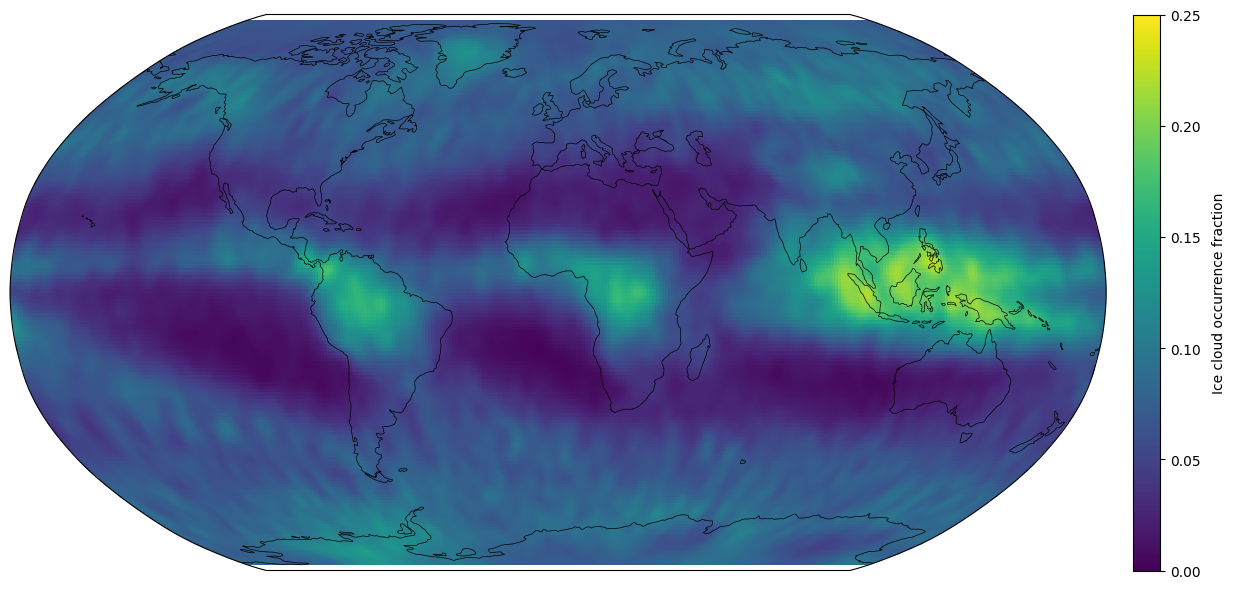

In [6]:
fig = plt.figure(figsize=(14, 6))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="k")
im = ax.pcolormesh(
    lon_ll, lat_ll, atl_ll,
    transform=ccrs.PlateCarree(),
    cmap="viridis", vmin=0, vmax=VMAX_LL,
)
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.03)
cbar.set_label("Ice cloud occurrence fraction", labelpad=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_1a_atl_ice_latlon_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_1a_atl_ice_latlon_2025.png")
plt.show()

In [7]:
print_stats(atl_ll, label="1a  ATL-TC ice — lat/lon (Jan–Dec 2025)")

─── 1a  ATL-TC ice — lat/lon (Jan–Dec 2025) ───
  Array shape : (180, 360)
  Valid cells : 61,920 / 64,800  (95.6%)
  Min         : 0.00270
  Max         : 0.22569
  Mean        : 0.06945
  Median      : 0.07006
  Std dev     : 0.03300
  p5          : 0.01753
  p25         : 0.05020
  p75         : 0.08389
  p95         : 0.12480



Saved Q1_1b_atl_ice_latheight_2025.png


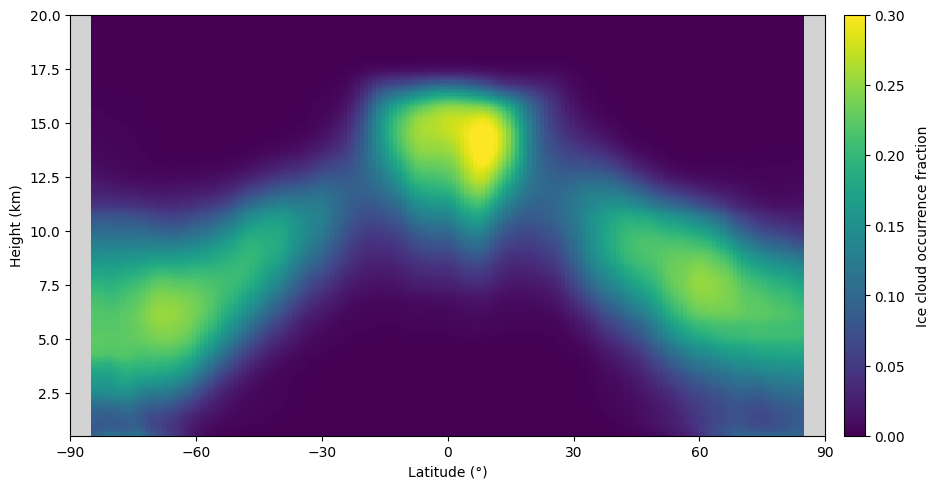

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(
    lat_lh, h_km[h_mask], atl_lh[:, h_mask].T,
    cmap="viridis", vmin=0, vmax=VMAX_LH, shading="auto",
)
cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label("Ice cloud occurrence fraction", labelpad=8)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Height (km)")
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(H_MIN_KM, H_MAX_KM)
ax.set_facecolor("lightgrey")
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_1b_atl_ice_latheight_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_1b_atl_ice_latheight_2025.png")
plt.show()

In [9]:
print_stats(atl_lh[:, h_mask], label="1b  ATL-TC ice — lat/height (Jan–Dec 2025)")
zonal_stats(atl_lh, lat_lh, h_km, h_mask, label="ATL-TC ice cloud occurrence")

─── 1b  ATL-TC ice — lat/height (Jan–Dec 2025) ───
  Array shape : (180, 196)
  Valid cells : 33,320 / 35,280  (94.4%)
  Min         : 0.00000
  Max         : 0.31842
  Mean        : 0.06704
  Median      : 0.02472
  Std dev     : 0.08049
  p5          : 0.00001
  p25         : 0.00038
  p75         : 0.12110
  p95         : 0.22576

─── Zonal statistics: ATL-TC ice cloud occurrence ───
  Latitude band                                  High >8km     Mid 4-8km      Low <4km
  Tropics        (|lat| < 30°)                      0.0925        0.0105        0.0000
  Subtropics   (30° – 60°)                          0.0548        0.1148        0.0195
  Extratropics  (|lat| >= 60°)                      0.0333        0.2135        0.1066



## 2 — AC-TC ice cloud occurrence (Jan–Dec 2025)

Annual mean ice cloud occurrence fraction from the synergetic classification
(AC_TC_2B, classes 19/20/21, combining ATLID + MSI + CPR).

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved Q1_2a_ac_ice_latlon_2025.png


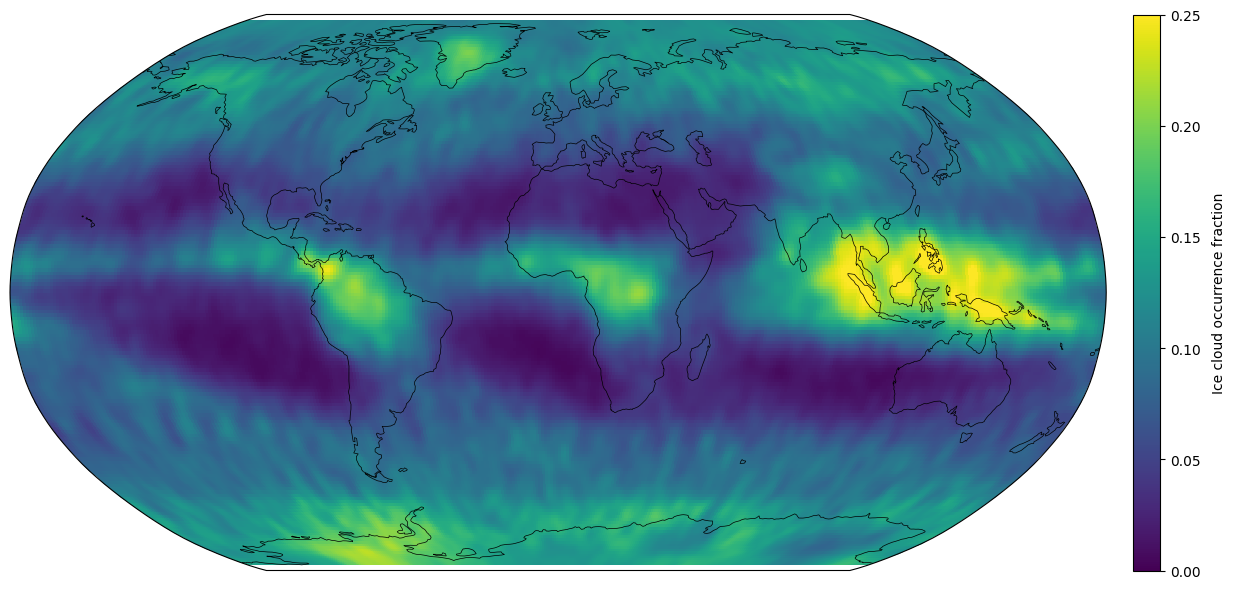

In [10]:
fig = plt.figure(figsize=(14, 6))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="k")
im = ax.pcolormesh(
    lon_ll, lat_ll, ac_ll,
    transform=ccrs.PlateCarree(),
    cmap="viridis", vmin=0, vmax=VMAX_LL,
)
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.03)
cbar.set_label("Ice cloud occurrence fraction", labelpad=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_2a_ac_ice_latlon_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_2a_ac_ice_latlon_2025.png")
plt.show()

In [11]:
print_stats(ac_ll, label="2a  AC-TC ice — lat/lon (Jan–Dec 2025)")

─── 2a  AC-TC ice — lat/lon (Jan–Dec 2025) ───
  Array shape : (180, 360)
  Valid cells : 61,920 / 64,800  (95.6%)
  Min         : 0.00375
  Max         : 0.28360
  Mean        : 0.09733
  Median      : 0.09794
  Std dev     : 0.04752
  p5          : 0.02097
  p25         : 0.06370
  p75         : 0.12656
  p95         : 0.17983



Saved Q1_2b_ac_ice_latheight_2025.png


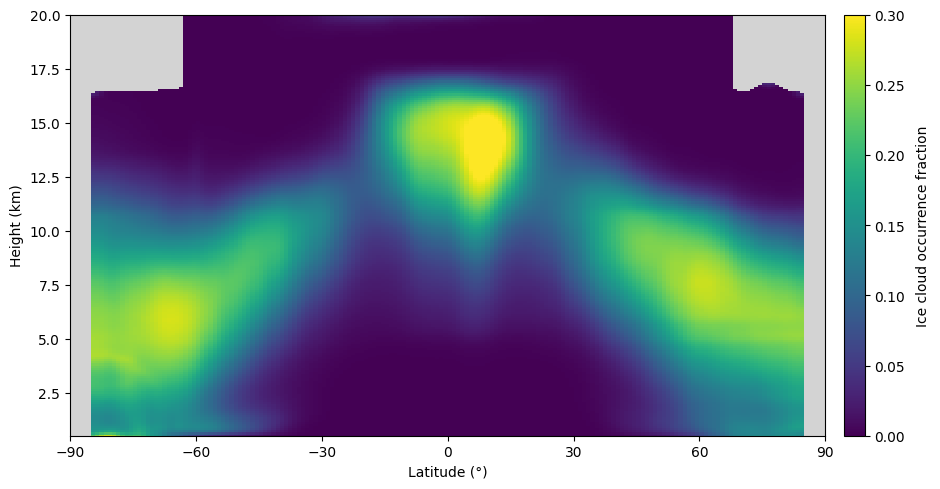

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(
    lat_lh, h_km[h_mask], ac_lh[:, h_mask].T,
    cmap="viridis", vmin=0, vmax=VMAX_LH, shading="auto",
)
cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02)
cbar.set_label("Ice cloud occurrence fraction", labelpad=8)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Height (km)")
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(H_MIN_KM, H_MAX_KM)
ax.set_facecolor("lightgrey")
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_2b_ac_ice_latheight_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_2b_ac_ice_latheight_2025.png")
plt.show()

In [13]:
print_stats(ac_lh[:, h_mask], label="2b  AC-TC ice — lat/height (Jan–Dec 2025)")
zonal_stats(ac_lh, lat_lh, h_km, h_mask, label="AC-TC ice cloud occurrence")

─── 2b  AC-TC ice — lat/height (Jan–Dec 2025) ───
  Array shape : (180, 196)
  Valid cells : 31,946 / 35,280  (90.5%)
  Min         : 0.00000
  Max         : 0.34647
  Mean        : 0.08521
  Median      : 0.05080
  Std dev     : 0.08985
  p5          : 0.00002
  p25         : 0.00188
  p75         : 0.15434
  p95         : 0.25342

─── Zonal statistics: AC-TC ice cloud occurrence ───
  Latitude band                                  High >8km     Mid 4-8km      Low <4km
  Tropics        (|lat| < 30°)                      0.1015        0.0223        0.0003
  Subtropics   (30° – 60°)                          0.0614        0.1395        0.0477
  Extratropics  (|lat| >= 60°)                      0.0565        0.2447        0.1643



## 3 — Ice cloud occurrence difference: AC-TC − ATL-TC (Jan–Dec 2025)

Positive values = AC-TC (synergetic) detects more ice than ATL-TC (lidar only).

In [14]:
ice_diff_ll = ac_ll - atl_ll
ice_diff_lh = ac_lh - atl_lh

print(f"Ice diff latlon   range: {np.nanmin(ice_diff_ll):.4f} – {np.nanmax(ice_diff_ll):.4f}")
print(f"Ice diff latheight range: {np.nanmin(ice_diff_lh):.4f} – {np.nanmax(ice_diff_lh):.4f}")

Ice diff latlon   range: -0.0183 – 0.0918
Ice diff latheight range: -0.0637 – 0.1893


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved Q1_3a_ice_diff_latlon_2025.png


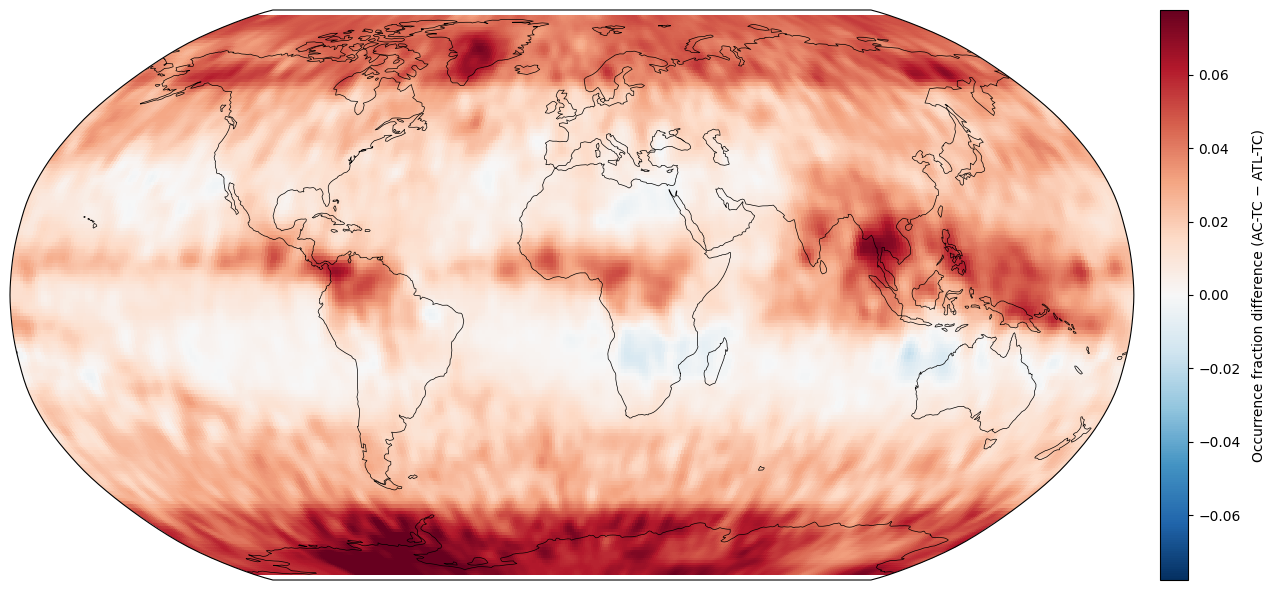

In [15]:
_vals = ice_diff_ll[~np.isnan(ice_diff_ll)]
vlim  = np.percentile(np.abs(_vals), 99)

fig = plt.figure(figsize=(14, 6))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="k")
im = ax.pcolormesh(
    lon_ll, lat_ll, ice_diff_ll,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-vlim, vmax=vlim,
)
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.03)
cbar.set_label("Occurrence fraction difference (AC-TC − ATL-TC)", labelpad=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_3a_ice_diff_latlon_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_3a_ice_diff_latlon_2025.png")
plt.show()

In [16]:
print_stats(ice_diff_ll, label="3a  Ice diff (AC-TC − ATL-TC) lat/lon (Jan–Dec 2025)",
           is_diff=True)

─── 3a  Ice diff (AC-TC − ATL-TC) lat/lon (Jan–Dec 2025) ───
  Array shape : (180, 360)
  Valid cells : 61,920 / 64,800  (95.6%)
  Min         : -0.01829
  Max         : 0.09183
  Mean        : 0.02787
  Median      : 0.02417
  Std dev     : 0.01956
  p5          : 0.00190
  p25         : 0.01217
  p75         : 0.04253
  p95         : 0.06428
  Cells > 0   : 60,435  (97.6%)  mean = 0.02863
  Cells < 0   : 1,485  (2.4%)  mean = -0.00309
  Cells = 0   : 0  (0.0%)



Saved Q1_3b_ice_diff_latheight_2025.png


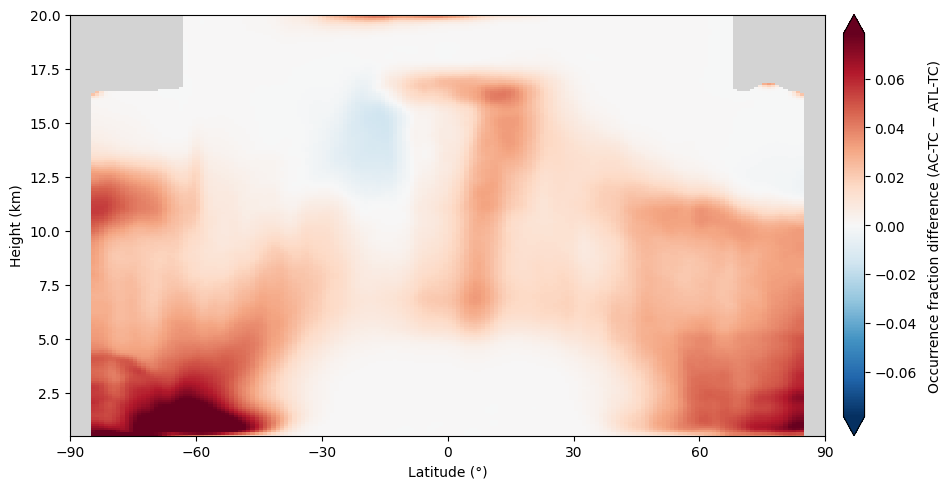

In [17]:
_sub  = ice_diff_lh[:, h_mask]
vlim  = np.nanpercentile(np.abs(_sub[~np.isnan(_sub)]), 99)

fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(
    lat_lh, h_km[h_mask], _sub.T,
    cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto",
)
cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, extend="both")
cbar.set_label("Occurrence fraction difference (AC-TC − ATL-TC)", labelpad=8)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Height (km)")
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(H_MIN_KM, H_MAX_KM)
ax.set_facecolor("lightgrey")
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_3b_ice_diff_latheight_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_3b_ice_diff_latheight_2025.png")
plt.show()

In [18]:
print_stats(ice_diff_lh[:, h_mask],
           label="3b  Ice diff (AC-TC − ATL-TC) lat/height (Jan–Dec 2025)",
           is_diff=True)
zonal_stats(ice_diff_lh, lat_lh, h_km, h_mask, label="Ice cloud occurrence difference")

─── 3b  Ice diff (AC-TC − ATL-TC) lat/height (Jan–Dec 2025) ───
  Array shape : (180, 196)
  Valid cells : 31,946 / 35,280  (90.5%)
  Min         : -0.01573
  Max         : 0.16227
  Mean        : 0.01529
  Median      : 0.01103
  Std dev     : 0.01802
  p5          : -0.00065
  p25         : 0.00034
  p75         : 0.02518
  p95         : 0.04825
  Cells > 0   : 28,830  (90.2%)  mean = 0.01724
  Cells < 0   : 3,112  (9.7%)  mean = -0.00272
  Cells = 0   : 4  (0.0%)

─── Zonal statistics: Ice cloud occurrence difference ───
  Latitude band                                  High >8km     Mid 4-8km      Low <4km
  Tropics        (|lat| < 30°)                      0.0091        0.0118        0.0002
  Subtropics   (30° – 60°)                          0.0066        0.0247        0.0282
  Extratropics  (|lat| >= 60°)                      0.0133        0.0312        0.0578



## 4 — All-cloud occurrence difference: AC-TC − ATL-TC (Jan–Dec 2025)

Total cloud (not just ice) occurrence difference between the synergetic and lidar-only
classifications. ATL-TC v2 uses codes 1–3 (all tropospheric clouds); AC-TC v2 uses
codes 7–21.

In [19]:
all_diff_ll = ac_all_ll - atl_all_ll
all_diff_lh = ac_all_lh - atl_all_lh

print(f"All-cloud diff latlon   range: {np.nanmin(all_diff_ll):.4f} – {np.nanmax(all_diff_ll):.4f}")
print(f"All-cloud diff latheight range: {np.nanmin(all_diff_lh):.4f} – {np.nanmax(all_diff_lh):.4f}")

All-cloud diff latlon   range: 0.0110 – 0.2076
All-cloud diff latheight range: -0.0183 – 0.7803


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/cartopy/mpl/feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


Saved Q1_4a_all_diff_latlon_2025.png


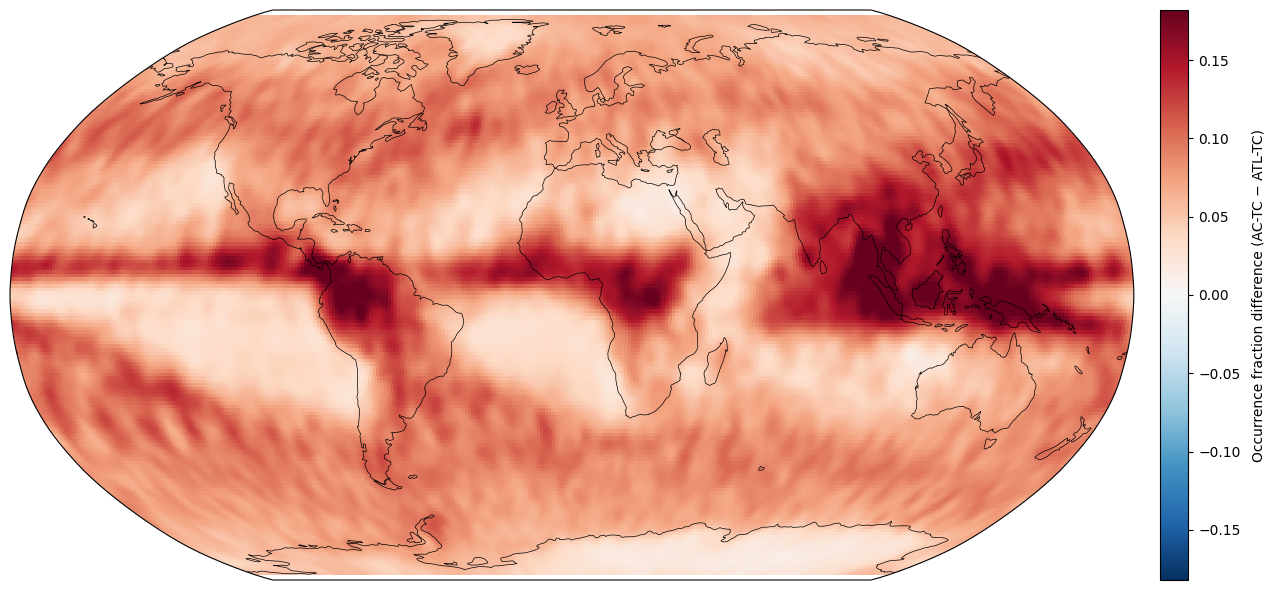

In [20]:
_vals = all_diff_ll[~np.isnan(all_diff_ll)]
vlim  = np.percentile(np.abs(_vals), 99)

fig = plt.figure(figsize=(14, 6))
ax  = fig.add_subplot(1, 1, 1, projection=ccrs.Robinson())
ax.set_global()
ax.add_feature(cfeature.COASTLINE, linewidth=0.5, color="k")
im = ax.pcolormesh(
    lon_ll, lat_ll, all_diff_ll,
    transform=ccrs.PlateCarree(),
    cmap="RdBu_r", vmin=-vlim, vmax=vlim,
)
cbar = plt.colorbar(im, ax=ax, orientation="vertical", pad=0.02, fraction=0.03)
cbar.set_label("Occurrence fraction difference (AC-TC − ATL-TC)", labelpad=8)
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_4a_all_diff_latlon_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_4a_all_diff_latlon_2025.png")
plt.show()

In [21]:
print_stats(all_diff_ll,
           label="4a  All-cloud diff (AC-TC − ATL-TC) lat/lon (Jan–Dec 2025)",
           is_diff=True)

─── 4a  All-cloud diff (AC-TC − ATL-TC) lat/lon (Jan–Dec 2025) ───
  Array shape : (180, 360)
  Valid cells : 61,920 / 64,800  (95.6%)
  Min         : 0.01100
  Max         : 0.20764
  Mean        : 0.07761
  Median      : 0.07497
  Std dev     : 0.03289
  p5          : 0.02955
  p25         : 0.05692
  p75         : 0.09256
  p95         : 0.14437
  Cells > 0   : 61,920  (100.0%)  mean = 0.07761
  Cells < 0   : 0  (0.0%)
  Cells = 0   : 0  (0.0%)



Saved Q1_4b_all_diff_latheight_2025.png


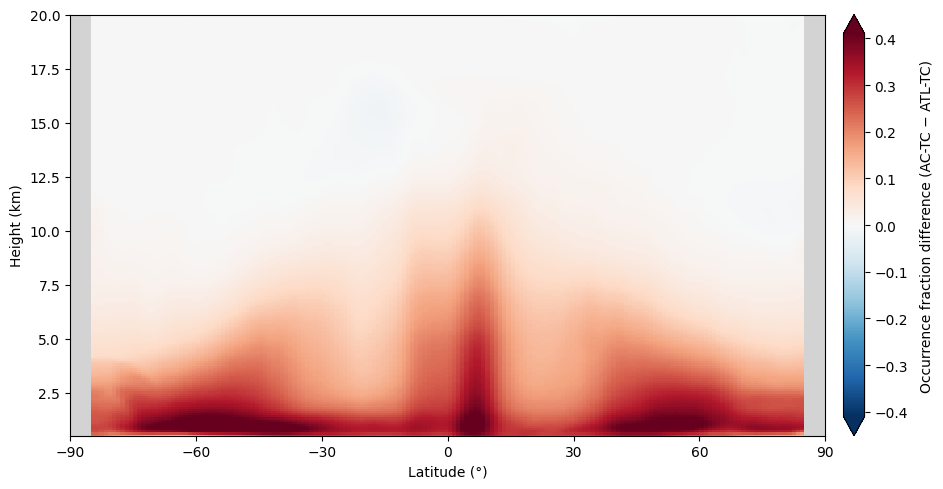

In [22]:
_sub  = all_diff_lh[:, h_mask]
vlim  = np.nanpercentile(np.abs(_sub[~np.isnan(_sub)]), 99)

fig, ax = plt.subplots(figsize=(10, 5))
mesh = ax.pcolormesh(
    lat_lh, h_km[h_mask], _sub.T,
    cmap="RdBu_r", vmin=-vlim, vmax=vlim, shading="auto",
)
cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", pad=0.02, extend="both")
cbar.set_label("Occurrence fraction difference (AC-TC − ATL-TC)", labelpad=8)
ax.set_xlabel("Latitude (°)")
ax.set_ylabel("Height (km)")
ax.set_xlim(-90, 90)
ax.set_xticks(range(-90, 91, 30))
ax.set_ylim(H_MIN_KM, H_MAX_KM)
ax.set_facecolor("lightgrey")
plt.tight_layout()
plt.savefig(OUT_DIR / "Q1_4b_all_diff_latheight_2025.png", dpi=300, bbox_inches="tight")
print("Saved Q1_4b_all_diff_latheight_2025.png")
plt.show()

In [23]:
print_stats(all_diff_lh[:, h_mask],
           label="4b  All-cloud diff (AC-TC − ATL-TC) lat/height (Jan–Dec 2025)",
           is_diff=True)
zonal_stats(all_diff_lh, lat_lh, h_km, h_mask, label="All-cloud occurrence difference")

─── 4b  All-cloud diff (AC-TC − ATL-TC) lat/height (Jan–Dec 2025) ───
  Array shape : (180, 196)
  Valid cells : 33,320 / 35,280  (94.4%)
  Min         : -0.01831
  Max         : 0.49790
  Mean        : 0.07581
  Median      : 0.01621
  Std dev     : 0.10744
  p5          : -0.00189
  p25         : 0.00028
  p75         : 0.12771
  p95         : 0.31529
  Cells > 0   : 29,174  (87.6%)  mean = 0.08697
  Cells < 0   : 4,146  (12.4%)  mean = -0.00273
  Cells = 0   : 0  (0.0%)

─── Zonal statistics: All-cloud occurrence difference ───
  Latitude band                                  High >8km     Mid 4-8km      Low <4km
  Tropics        (|lat| < 30°)                      0.0213        0.1438        0.2448
  Subtropics   (30° – 60°)                          0.0061        0.1135        0.2956
  Extratropics  (|lat| >= 60°)                      0.0014        0.0543        0.2524

